# Code for *“Bipartitioning of Graph States for Distributed Measurement-Based Quantum Computing”*
This notebook contains the scripts required to reproduce the results from the paper:

> *“Bipartitioning of Graph States for Distributed Measurement-Based Quantum Computing”*

Code ran with Python v3.14.6

### Required Python Packages

- `rustworkx` (ran with v0.18.1)
- `numpy` (ran with v2.4.6)
- `kahypar` (ran with v1.3.7)
- `galois` (ran with v0.4.11)


## Code for hypergraph partitioning

In [ ]:
import rustworkx as rx
import numpy as np
import kahypar
import galois
import matplotlib.pyplot as plt
from partition_builder import random_partition
from cut_rank_annealing import cut_rank_annealing_row_formula,cut_rank_annealing_direct

import random
import time

GF=galois.GF(2)

def graphstate_to_hypergraph(A):
    """
    Algorithm 2 from paper (Appendix B)
    """
    n_qubit = A.shape[0]
    gates = []
    for i in range(n_qubit):
        for j in range(i+1,n_qubit):
            if A[i,j] == 1:
                gates.append((i,j))
    
    g_idx  = {e: n_qubit + m for m, e in enumerate(gates)} # map edges to CZ gate number
    
    hyperedges = []
    for i in range(n_qubit):
        neighbor_indices = np.flatnonzero(A[i]) 
        hyperedge = [i] + [g_idx[tuple(sorted((i, j)))] for j in neighbor_indices]
        hyperedges.append(hyperedge)

    node_weights = [10000]*n_qubit + [1]*len(gates) # moving gate nodes should be essentially free
    edge_weights = [1]*len(hyperedges)

    return hyperedges, node_weights, edge_weights



def partition_kahypar(A,seed=-1):
    """
    Run KaHyPar on the graph
    """
    hyperedges, nw, ew = graphstate_to_hypergraph(A)
    num_nodes, num_edges = len(nw), len(hyperedges)
    
    hyperedges_flat, hyperedge_idx = [0], [] # convert to kahypar format
    for edge in hyperedges:
        hyperedge_idx.extend(edge); hyperedges_flat.append(len(hyperedge_idx))

    hg = kahypar.Hypergraph(num_nodes, num_edges, hyperedges_flat, hyperedge_idx, 2, ew, nw)
    ctx = kahypar.Context()
    # config files can be found here: https://github.com/kahypar/kahypar/tree/master/config
    ctx.loadINIconfiguration("km1_rKaHyPar_sea20.ini")  
    ctx.setK(2)
    ctx.setSeed(seed)
    
    assert(A.shape[0]==num_edges) # num qubits = num edges of hypergraph
    eps = 0.005
    # test if epsilon allows for freely moving auxiliary nodes
    # num_edges = |V| (for each qubit we introduced one hyperedge)
    # num_nodes-num_edges = |E| since num_nodes = |V|+|E|
    eps_min = 1/(1+10000*num_edges/(num_nodes-num_edges))
    assert(eps>eps_min)
    
    ctx.setEpsilon(eps)
    ctx.suppressOutput(True)

    kahypar.partition(hg, ctx)
    blocks = [hg.blockID(i) for i in range(num_nodes)]

    partition1 = []
    for i in range(A.shape[0]):
        if blocks[i] == 0:
            partition1.append(i)
    partition2 = list(set(range(A.shape[0]))-set(partition1))

    assert(len(partition1)==len(partition2))

    return np.linalg.matrix_rank(A[partition1][:,partition2])


def annealing_cut_rank_direct(A,num_sweeps,seed=1234,check_result=False):
    """
    Simulated annealing by direct rank calculations
    """
    adj_mat =[list([int(aa) for aa in a]) for a in A]
    random.seed(seed)
    partition = random_partition(adj_mat, 0.5)
    temperatures=np.linspace(1.0,0.1,num_sweeps)

    cut_rank_annealing_direct(partition, temperatures, False)
    if check_result:
        assert(np.linalg.matrix_rank(A[partition.rows][:,partition.columns])==partition.cut_rank)
    
    return partition.cut_rank


def annealing_cut_rank(A,num_sweeps,seed=1234,check_result=False):
    """
    Simulated annealing by incremental update
    """
    adj_mat =[list([int(aa) for aa in a]) for a in A]
    random.seed(seed)
    partition = random_partition(adj_mat, 0.5)
    temperatures=np.linspace(1.0,0.1,num_sweeps)

    cut_rank_annealing_row_formula(partition, temperatures, False)
    if check_result:
            assert(np.linalg.matrix_rank(A[partition.rows][:,partition.columns])==partition.cut_rank)
    
    return partition.cut_rank


def write_table(path, columns: dict, index=None, width=14, fmt=""):
    """
    Helper to write results to txt file
    """
    headers = list(columns)
    rows = list(zip(*columns.values())) 
    if index is None:
        index = range(1, len(rows) + 1)

    with open(path, "w", encoding="utf-8") as f:
        f.write(f"{'n':<{width}}" + "".join(f"{h:<{width}}" for h in headers) + "\n")
        for n, row in zip(index, rows):
            f.write(f"{n:<{width}}" + "".join(f"{v:<{width}{fmt}}" for v in row) + "\n")



## Grid Graphs

In [2]:
G = rx.generators.grid_graph(20,20,multigraph=False)
A = GF(np.array(rx.adjacency_matrix(G),dtype=int))

timing = []
grid_rank=[]

for n in range(3,21):
    G = rx.generators.grid_graph(n,n,multigraph=False)
    A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
    rlist=[]
    start=time.time()
    for seed in range(100):
        r = annealing_cut_rank(A,10,seed=seed)
        rlist.append(r)
    end=time.time()
    print(end-start)
    grid_rank.append(float(np.mean(rlist)))
    timing.append((end-start)/100)
    

0.18822884559631348
0.37625885009765625
0.8349125385284424
1.5831928253173828
2.903381824493408
4.944466829299927
8.026579141616821
12.574121475219727
18.757648229599
29.091265439987183
41.86686587333679
60.435118675231934
78.62776899337769
104.70966649055481
142.5648512840271
191.514545917511
255.4155478477478
320.46500158309937


In [3]:
timing_direct = []
grid_rank_direct=[]

for n in range(3,21):
    G = rx.generators.grid_graph(n,n,multigraph=False)
    A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
    rlist=[]
    start=time.time()
    for seed in range(1):
        r = annealing_cut_rank_direct(A,10,seed=seed)
        rlist.append(r)
    end=time.time()
    print(end-start)
    grid_rank_direct.append(np.mean(rlist))
    timing_direct.append((end-start)/1)

0.0026531219482421875
0.009514331817626953
0.036058902740478516
0.11579585075378418
0.3637821674346924
0.9356956481933594
2.195194959640503
4.999439716339111
10.165892362594604
20.33295702934265
37.046260595321655
65.4740948677063
114.42145419120789
183.75417923927307
337.593373298645
503.1453342437744
726.3909618854523
1154.1597964763641


In [4]:
grid_rank_start=[]
for n in range(3,21):
    G = rx.generators.grid_graph(n,n,multigraph=False)
    A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
    adj_mat =[list([int(aa) for aa in a]) for a in A]
    rlist=[]
    start=time.time()
    for seed in range(100):
        random.seed(seed)
        partition = random_partition(adj_mat, 0.5)
        rlist.append(partition.cut_rank)
    end=time.time()
    print(end-start)
    grid_rank_start.append(float(np.mean(rlist)))
    

0.00396275520324707
0.008437395095825195
0.017550230026245117
0.030754804611206055
0.05696702003479004
0.09887480735778809
0.16005563735961914
0.23694610595703125
0.35579967498779297
0.5079190731048584
0.70082688331604
0.9726424217224121
1.3080406188964844
1.689884901046753
2.128552198410034
2.731178045272827
3.538095474243164
4.205990791320801


In [5]:
grid_results = {"r_dev" : np.round([r-(n+3) for (n,r) in enumerate(grid_rank)],2), 
     "r_start" : grid_rank_start, 
     "r_end": np.round(grid_rank,2),
     "t_dir": np.round(timing_direct,4),
     "t_incr": np.round(timing,4)}

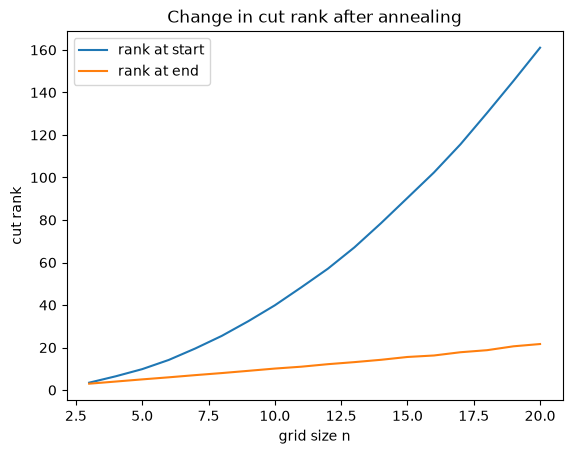

In [6]:
plt.plot(range(3,21),grid_results["r_start"],label="rank at start")
plt.plot(range(3,21),grid_results["r_end"],label="rank at end")
plt.title("Change in cut rank after annealing")
plt.xlabel("grid size n")
plt.ylabel("cut rank")

plt.legend()

Text(0, 0.5, 'time in sec.')

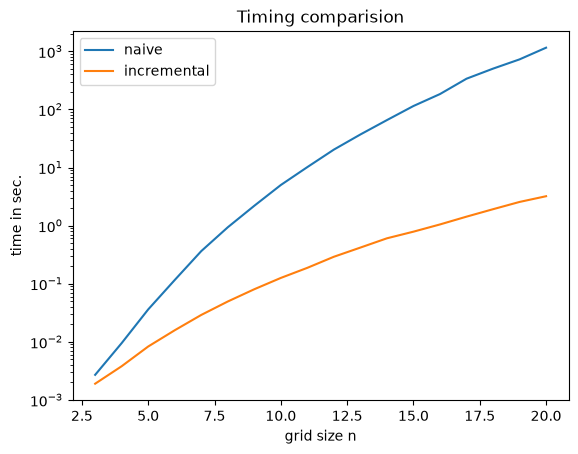

In [7]:
plt.plot(range(3,21),grid_results["t_dir"],label="naive")
plt.plot(range(3,21),grid_results["t_incr"],label="incremental")
plt.legend()
plt.yscale("log")
plt.title("Timing comparision")
plt.xlabel("grid size n")
plt.ylabel("time in sec.")


Text(0.5, 1.0, 'Deviation from min cut rank on grid')

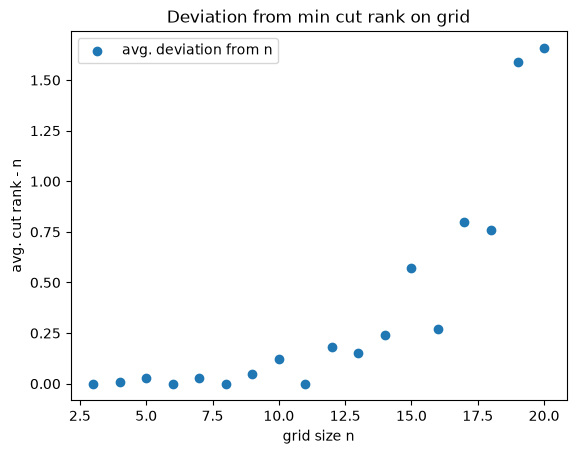

In [8]:
plt.scatter(range(3,21),grid_results["r_dev"],label="avg. deviation from n")
plt.legend()
plt.xlabel("grid size n")
plt.ylabel("avg. cut rank - n")
plt.title("Deviation from min cut rank on grid")

In [9]:
write_table(
    "grid_result.txt",
    grid_results,
    index=range(3,21)
)

## Random Graphs

In [10]:
graph_sizes = list(range(50,201,20))
num_samples = 100  # in paper we used 100

In [11]:
cut_ranks_annealing_5 = []
cut_ranks_kahypar_5 = []

cut_ranks_annealing_5_std = []
cut_ranks_kahypar_5_std = []
from tqdm import tqdm
for n in graph_sizes:
    r1list=[]
    r2list=[]
    for seed in tqdm(range(num_samples)):
        G = rx.undirected_gnp_random_graph(n,5/n,seed=seed).to_directed().to_undirected(multigraph=False)
        A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
        
        r1 = []
        r2 = []
        for seed2 in range(10):
            r1.append(partition_kahypar(A,seed=seed2))
            r2.append(annealing_cut_rank(A,10,seed=seed2,check_result=True))
        r1list.append(min(r1))
        r2list.append(min(r2))
        
    cut_ranks_kahypar_5.append(float(np.mean(r1list)))
    cut_ranks_annealing_5.append(float(np.mean(r2list)))
    
    cut_ranks_kahypar_5_std.append(float(np.std(r1list)))
    cut_ranks_annealing_5_std.append(float(np.std(r2list)))

100%|██████████| 100/100 [21:52<00:00, 13.13s/it]


In [12]:
cut_ranks_annealing_10 = []
cut_ranks_kahypar_10 = []

cut_ranks_annealing_10_std = []
cut_ranks_kahypar_10_std = []


for n in graph_sizes:
    r1list=[]
    r2list=[]
    for seed in tqdm(range(num_samples)):
        G = rx.undirected_gnp_random_graph(n,10/n,seed=seed).to_directed().to_undirected(multigraph=False)
        A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
        
        r1 = []
        r2 = []
        for seed2 in range(10):
            r1.append(partition_kahypar(A,seed=seed2))
            r2.append(annealing_cut_rank(A,10,seed=seed2,check_result=True))
        r1list.append(min(r1))
        r2list.append(min(r2))
        
    cut_ranks_kahypar_10.append(float(np.mean(r1list)))
    cut_ranks_annealing_10.append(float(np.mean(r2list)))
    
    cut_ranks_kahypar_10_std.append(float(np.std(r1list)))
    cut_ranks_annealing_10_std.append(float(np.std(r2list)))

100%|██████████| 100/100 [52:19<00:00, 31.39s/it]


In [13]:
cut_ranks_annealing_5_LC = []
cut_ranks_kahypar_5_LC = []

cut_ranks_annealing_5_LC_std = []
cut_ranks_kahypar_5_LC_std = []

for n in graph_sizes:
    r1list=[]
    r2list=[]
    for seed in tqdm(range(num_samples)):
        G = rx.undirected_gnp_random_graph(n,5/n,seed=seed).to_directed().to_undirected(multigraph=False)
        random.seed(seed)
        comp_nodes = random.sample(range(n), n//3)
        for i in comp_nodes:
            G = rx.local_complement(G,i)

        A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
        
        r1 = []
        r2 = []
        for seed2 in range(10):
            r1.append(partition_kahypar(A,seed=seed2))
            r2.append(annealing_cut_rank(A,10,seed=seed2,check_result=True))
        r1list.append(min(r1))
        r2list.append(min(r2))
        
        
    cut_ranks_kahypar_5_LC.append(float(np.mean(r1list)))
    cut_ranks_annealing_5_LC.append(float(np.mean(r2list)))
    
    cut_ranks_kahypar_5_LC_std.append(float(np.std(r1list)))
    cut_ranks_annealing_5_LC_std.append(float(np.std(r2list)))

100%|██████████| 100/100 [30:14<00:00, 18.14s/it]


In [14]:
cut_ranks_annealing_10_LC = []
cut_ranks_kahypar_10_LC = []

cut_ranks_annealing_10_LC_std = []
cut_ranks_kahypar_10_LC_std = []

for n in graph_sizes:
    r1list=[]
    r2list=[]
    for seed in tqdm(range(num_samples)):
        G = rx.undirected_gnp_random_graph(n,10/n,seed=seed).to_directed().to_undirected(multigraph=False)
        random.seed(seed)
        comp_nodes = random.sample(range(n), n//2)
        for i in comp_nodes:
            G = rx.local_complement(G,i)
        A = GF(np.array(rx.adjacency_matrix(G),dtype=int))
        
        r1 = []
        r2 = []
        for seed2 in range(10):
            r1.append(partition_kahypar(A,seed=seed2))
            r2.append(annealing_cut_rank(A,10,seed=seed2,check_result=True))
        r1list.append(min(r1))
        r2list.append(min(r2))
        
        
    cut_ranks_kahypar_10_LC.append(float(np.mean(r1list)))
    cut_ranks_annealing_10_LC.append(float(np.mean(r2list)))
    
    cut_ranks_kahypar_10_LC_std.append(float(np.std(r1list)))
    cut_ranks_annealing_10_LC_std.append(float(np.std(r2list)))

100%|██████████| 100/100 [1:02:12<00:00, 37.32s/it]


In [15]:
graph_result={"ra_5": cut_ranks_annealing_5, 
     "rh_5": cut_ranks_kahypar_5,
     "ra_10": cut_ranks_annealing_10, 
     "rh_10": cut_ranks_kahypar_10,
     "ra_5_std": np.round(cut_ranks_annealing_5_std,2), 
     "rh_5_std": np.round(cut_ranks_kahypar_5_std,2),
     "ra_10_std": np.round(cut_ranks_annealing_10_std,2), 
     "rh_10_std": np.round(cut_ranks_kahypar_10_std,2)}

graph_LC_result={"ra_5": cut_ranks_annealing_5_LC, 
     "rh_5": cut_ranks_kahypar_5_LC,
     "ra_10": cut_ranks_annealing_10_LC, 
     "rh_10": cut_ranks_kahypar_10_LC,
     "ra_5_std": np.round(cut_ranks_annealing_5_LC_std,2), 
     "rh_5_std": np.round(cut_ranks_kahypar_5_LC_std,2),
     "ra_10_std": np.round(cut_ranks_annealing_10_LC_std,2), 
     "rh_10_std": np.round(cut_ranks_kahypar_10_LC_std,2)}

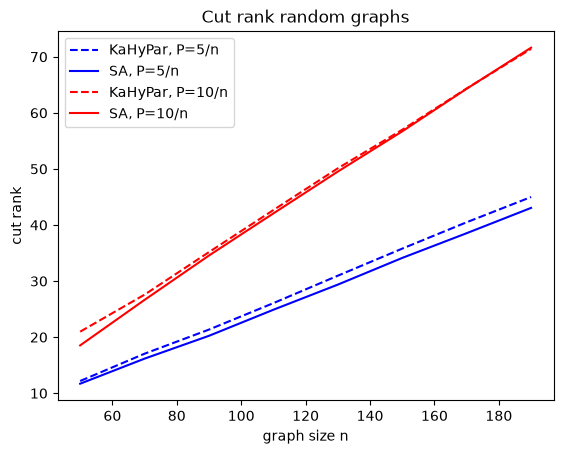

In [16]:
plt.plot(graph_sizes,graph_result["rh_5"],label="KaHyPar, P=5/n",linestyle="--",color="blue")
plt.plot(graph_sizes,graph_result["ra_5"],label="SA, P=5/n",color="blue")
plt.plot(graph_sizes,graph_result["rh_10"],label="KaHyPar, P=10/n",linestyle="--",color="red")
plt.plot(graph_sizes,graph_result["ra_10"],label="SA, P=10/n",color="red")
plt.title("Cut rank random graphs")
plt.xlabel("graph size n")
plt.ylabel("cut rank")
plt.legend()

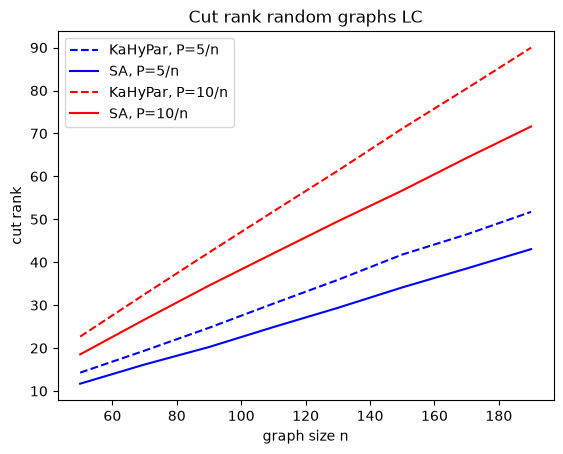

In [17]:
plt.plot(graph_sizes,graph_LC_result["rh_5"],label="KaHyPar, P=5/n",linestyle="--",color="blue")
plt.plot(graph_sizes,graph_LC_result["ra_5"],label="SA, P=5/n",color="blue")
plt.plot(graph_sizes,graph_LC_result["rh_10"],label="KaHyPar, P=10/n",linestyle="--",color="red")
plt.plot(graph_sizes,graph_LC_result["ra_10"],label="SA, P=10/n",color="red")
plt.title("Cut rank random graphs LC")
plt.xlabel("graph size n")
plt.ylabel("cut rank")
plt.legend()

In [18]:
write_table(
    "random_graphs_results.txt",
    graph_result,
    index=graph_sizes
)


In [19]:
write_table(
    "random_graphs_LC_results.txt",
    graph_LC_result,
    index=graph_sizes
)

## QAOA

### Code to generate QAOA instance

In [20]:

def generate_terms(num_qubits,num_terms,w, seed):
    """
    Generates random terms of a QAOA Hamiltonian.
    seeds used in paper are 42
    """
    random.seed(seed+num_terms)
    terms = set()
    while (len(terms) < num_terms):
        nmb = set()
        for _ in range(w):
            nmb.add(random.randint(0,num_qubits-1))
        if len(nmb) != w:
            continue
        nmb=list(nmb)
        nmb.sort()
        terms.add(tuple(nmb))
    
    return list(terms)
            

def generate_qubo_graph(num_qubits,num_terms,w,seed):
    """
    Generates MBQC graph state for a random QAOA instance with given number of qubits, 
    number of terms in the Hamiltonian and locality w.
    """
    terms = generate_terms(num_qubits,num_terms,w, seed)
    adj_matrix = np.zeros((num_qubits+num_terms,num_qubits+num_terms))
    for (n,term) in enumerate(terms):
        for j in term:
            adj_matrix[n+num_qubits][j] = 1
            adj_matrix[j][n+num_qubits] = 1
                
    return adj_matrix

def simple_graph_from_adj(A: np.ndarray) -> rx.PyGraph:
    """
    Get undirected graph from a 0/1 adjacency matrix.
    """
    n = A.shape[0]
    G = rx.PyGraph(multigraph=False)
    G.add_nodes_from(range(n))
    iu = np.triu(np.asarray(A) != 0, k=1).nonzero()
    G.add_edges_from([(int(i), int(j), 1) for i, j in zip(*iu)])
    
    return G


qaoa_seed = 42

### Baseline results from KaHyPar (best out of 100 runs)

In [21]:
kahypar_qaoa=[]
for t in [100,200]:
    for w in [2,3]:
        A = generate_qubo_graph(40,t,w,qaoa_seed)
        cut_rank_list=[]
        for seed in range(100):
            cut_rank_list.append(partition_kahypar(A,seed=seed))
        
        kahypar_qaoa.append(min(cut_rank_list))
        print(w,t,min(cut_rank_list))

2 100 11
3 100 23
2 200 20
3 200 28


### Run Simulated Annealing

In [22]:
A = generate_qubo_graph(40,200,2,qaoa_seed)
cut_rank_qaoa_200_2 = [[] for _ in range(3)] 
for (n,num_sweeps) in enumerate([10,100,1000]):
    for seed in range(10):
        cut_rank_qaoa_200_2[n].append(annealing_cut_rank(A,num_sweeps,seed=seed,check_result=True))


In [23]:
A = generate_qubo_graph(40,200,3,qaoa_seed)
cut_rank_qaoa_200_3 = [[] for _ in range(3)] 
for (n,num_sweeps) in enumerate([10,100,1000]):
    for seed in range(10):
        cut_rank_qaoa_200_3[n].append(annealing_cut_rank(A,num_sweeps,seed=seed,check_result=True))

In [24]:
A = generate_qubo_graph(40,100,2,qaoa_seed)
cut_rank_qaoa_100_2 = [[] for _ in range(3)] 
for (n,num_sweeps) in enumerate([10,100,1000]):
    for seed in range(10):
        cut_rank_qaoa_100_2[n].append(annealing_cut_rank(A,num_sweeps,seed=seed,check_result=True))

In [25]:
A = generate_qubo_graph(40,100,3,qaoa_seed)
cut_rank_qaoa_100_3 = [[] for _ in range(3)] 
for (n,num_sweeps) in enumerate([10,100,1000]):
    for seed in range(10):
        cut_rank_qaoa_100_3[n].append(annealing_cut_rank(A,num_sweeps,seed=seed,check_result=True))

In [26]:
qaoa_result={"100_2" : np.min(cut_rank_qaoa_100_2,axis=1), 
     "100_3" : np.min(cut_rank_qaoa_100_3,axis=1), 
     "200_2" : np.min(cut_rank_qaoa_200_2,axis=1), 
     "200_3" : np.min(cut_rank_qaoa_200_3,axis=1)}

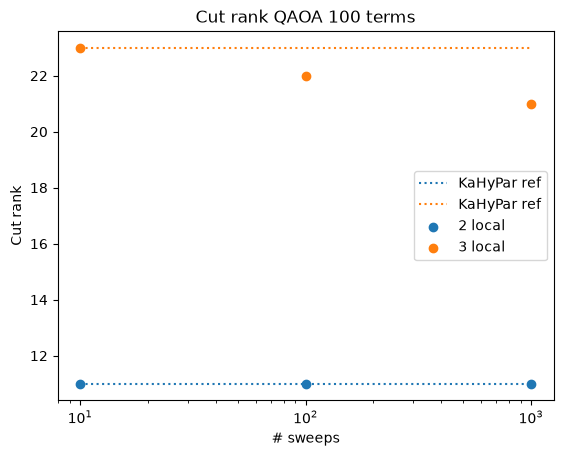

In [27]:

plt.plot([10,1000],[kahypar_qaoa[0],kahypar_qaoa[0]],linestyle=":",label="KaHyPar ref")
plt.plot([10,1000],[kahypar_qaoa[1],kahypar_qaoa[1]],linestyle=":",label="KaHyPar ref")

plt.scatter([10,100,1000],qaoa_result["100_2"],label="2 local")
plt.scatter([10,100,1000],qaoa_result["100_3"],label="3 local")
plt.title("Cut rank QAOA 100 terms")
plt.xscale("log")
plt.ylabel("Cut rank")
plt.xlabel("# sweeps")
plt.legend()

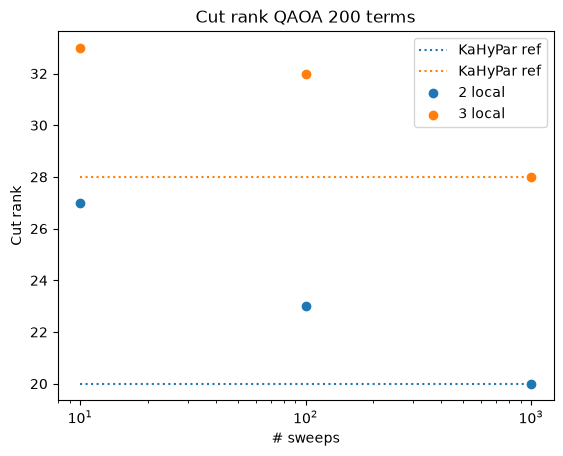

In [28]:

plt.plot([10,1000],[kahypar_qaoa[2],kahypar_qaoa[2]],linestyle=":",label="KaHyPar ref")
plt.plot([10,1000],[kahypar_qaoa[3],kahypar_qaoa[3]],linestyle=":",label="KaHyPar ref")

plt.scatter([10,100,1000],qaoa_result["200_2"],label="2 local")
plt.scatter([10,100,1000],qaoa_result["200_3"],label="3 local")
plt.title("Cut rank QAOA 200 terms")
plt.xscale("log")
plt.ylabel("Cut rank")
plt.xlabel("# sweeps")
plt.legend()

In [29]:
write_table(
    "qaoa_result.txt",
    qaoa_result,
    index=[10,100,1000]
)

### Timings

In [30]:
for t in [100,200]:
    for w in [2,3]:

        A = generate_qubo_graph(40,t,w,qaoa_seed)

        start=time.time()
        for seed in range(10):
            annealing_cut_rank(A,1000,seed=seed)
        end=time.time()

        print(w,t,(end-start)/10)

2 100 14.622094440460206
3 100 20.40793297290802
2 200 70.71812701225281
3 200 100.33418393135071


In [31]:
for t in [100,200]:
    for w in [2,3]:

        A = generate_qubo_graph(40,t,w,qaoa_seed)

        start=time.time()
        for seed in range(10):
            partition_kahypar(A,seed=seed)
        end=time.time()

        print(w,t,(end-start)/10)

2 100 0.027862143516540528
3 100 0.027030110359191895
2 200 0.037564635276794434
3 200 0.040266990661621094


### LC on QAOA

In [32]:
cut_rank_lc_1 = []


A = generate_qubo_graph(40,200,3,qaoa_seed)
G = simple_graph_from_adj(A)

for seed in range(10):
    random.seed(seed)
    comp_nodes = random.sample(range(40), 1)
    for i in comp_nodes:
        G = rx.local_complement(G,i)
    A=rx.adjacency_matrix(G)
    ranks = []
    for seed2 in range(100):
        ranks.append(int(partition_kahypar(A,seed=seed2)))
    cut_rank_lc_1.append(min(ranks))


In [33]:
print(np.mean(cut_rank_lc_1))
print(min(cut_rank_lc_1))
print(max(cut_rank_lc_1))

30.6
28
32


In [34]:
cut_rank_lc_5 = []


A = generate_qubo_graph(40,200,3,qaoa_seed)
G = simple_graph_from_adj(A)

for seed in range(10):
    random.seed(seed)
    comp_nodes = random.sample(range(40), 5)
    for i in comp_nodes:
        G = rx.local_complement(G,i)
    A=rx.adjacency_matrix(G)
    ranks = []
    for seed2 in range(100):
        ranks.append(int(partition_kahypar(A,seed=seed2)))
    cut_rank_lc_5.append(min(ranks))


In [35]:
print(np.mean(cut_rank_lc_5))
print(min(cut_rank_lc_5))
print(max(cut_rank_lc_5))

31.3
28
34


In [36]:
cut_rank_lc_10 = []


A = generate_qubo_graph(40,200,3,qaoa_seed)
G = simple_graph_from_adj(A)

for seed in range(10):
    random.seed(seed)
    comp_nodes = random.sample(range(40), 10)
    for i in comp_nodes:
        G = rx.local_complement(G,i)
    A=rx.adjacency_matrix(G)
    ranks = []
    for seed2 in range(100):
        ranks.append(int(partition_kahypar(A,seed=seed2)))
    cut_rank_lc_10.append(min(ranks))


In [37]:
print(np.mean(cut_rank_lc_10))
print(min(cut_rank_lc_10))
print(max(cut_rank_lc_10))

34.2
31
41


In [38]:
write_table(
    "qaoa_LC.txt",
    {"min" : [kahypar_qaoa[3],min(cut_rank_lc_1),min(cut_rank_lc_5),min(cut_rank_lc_10)], 
     "max" : [kahypar_qaoa[3],max(cut_rank_lc_1),max(cut_rank_lc_5),max(cut_rank_lc_10)], 
     "mean" : [kahypar_qaoa[3],np.mean(cut_rank_lc_1),np.mean(cut_rank_lc_5),np.mean(cut_rank_lc_10)],
     },
    index=[0,1,5,10]
)